<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8009/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering (Ingeniería de Características)

¿Qué es una característica (feature) y por qué necesitamos el feature engineering?

Básicamente, todos los algoritmos de Machine Learning utilizan algunos datos de entrada para generar salidas. Estos datos de entrada comprenden features, que generalmente están en forma de columnas estructuradas. En ese sentido, los esfuerzos de feature engineering tienen principalmente dos objetivos:

- Preparar el dataset de entrada adecuado, compatible con los requisitos del algoritmo de aprendizaje automático.
- Mejorar el rendimiento de los modelos de aprendizaje automático.

Un [artículo de Harvard Business Review](https://hbr.org/2018/04/if-your-data-is-bad-your-machine-learning-tools-are-useless) afirmó que:

*"La mala calidad de los datos es el enemigo número uno para el uso generalizado y rentable del aprendizaje automático. Las exigencias de calidad del aprendizaje automático son altas, y los datos deficientes pueden mostrar su fea cabeza dos veces: tanto en los datos históricos utilizados para entrenar el modelo predictivo como en los nuevos datos utilizados por ese modelo para tomar decisiones futuras. Para asegurarse de tener los datos correctos para el aprendizaje automático, debe tener un programa de calidad agresivo y bien ejecutado."*

En este notebook analizaremos en profundidad distintas técnicas de feature engineering:

1. Transformaciones no lineales
2. Feature Scaling (normalización, estandarización)
3. Binning (discretización)
4. Encoding (ordinal, rare, OHE, frequency, target)
5. Variables temporales
6. Variables agregadas
7. Interacciones y variables derivadas

Para ello emplearemos el dataset `diamonds` de seaborn, el cual originalmente contiene datos de 53,940 diamantes con atributos físicos y el precio de venta; sin embargo, se le ha añadido de manera sintética la fecha de venta.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler,MaxAbsScaler, OrdinalEncoder, PolynomialFeatures)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

In [ ]:
df = pd.read_csv('diamonds_sale_date.csv', parse_dates=['sale_date'])
print(df.shape)
df.head()

(53940, 11)


,carat,cut,color,clarity,depth,table,price,x,y,z,sale_date
0,0.380,Very Good,F,VS2,59.700,57.000,752,4.730,4.790,2.840,01/01/2020
1,1.030,Ideal,F,SI1,61.300,56.000,6059,6.510,6.550,4.000,01/01/2020
2,1.010,Premium,F,SI2,61.800,56.000,4257,6.430,6.380,3.960,01/01/2020
3,0.770,Premium,J,SI1,61.800,59.000,1909,5.820,5.860,3.610,01/01/2020
4,1.090,Ideal,E,VS2,60.600,57.000,8158,6.660,6.670,4.040,01/01/2020


### Diccionario de Datos

**carat**: Peso del diamante. Es la medida más relevante para determinar su tamaño.

**cut** (Ordinal): Calidad del corte del diamante.  
Opciones (de menor a mayor calidad):  
Fair < Good < Very Good < Premium < Ideal

**color** (Ordinal): Grado de color del diamante.  
Opciones (de peor a mejor calidad):  
J < I < H < G < F < E < D  
(D es el mejor: más incoloro)

**clarity** (Ordinal): Nivel de pureza del diamante.  
Opciones (de menor a mayor calidad):  
I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF  
(IF = Internally Flawless, máxima pureza)

**depth**: Profundidad total expresada como porcentaje respecto al ancho promedio del diamante.

**table**: Ancho de la parte superior del diamante (tabla), expresado como porcentaje del ancho máximo.

**price**: Precio de venta del diamante en dólares estadounidenses.

**x**: Longitud del diamante en milímetros.

**y**: Ancho del diamante en milímetros.

**z**: Profundidad del diamante en milímetros.

**sale_date**: Sale date of the diamond.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53940 non-null  float64
 1   cut        53940 non-null  object 
 2   color      53940 non-null  object 
 3   clarity    53940 non-null  object 
 4   depth      53940 non-null  float64
 5   table      53940 non-null  float64
 6   price      53940 non-null  int64  
 7   x          53940 non-null  float64
 8   y          53940 non-null  float64
 9   z          53940 non-null  float64
 10  sale_date  53940 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 4.5+ MB


In [ ]:
cols_num = df.select_dtypes('number').columns.tolist()
cols_cat = df.select_dtypes('object').columns.tolist()
print('Numéricas :', cols_num)
print('Categóricas:', cols_cat)

for col in cols_cat:
    print(f'\n{col} — {df[col].nunique()} categorías:')
    print(df[col].value_counts())

Numéricas : ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
Categóricas: ['cut', 'color', 'clarity', 'sale_date']

cut — 5 categorías:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

color — 7 categorías:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

clarity — 8 categorías:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

sale_date — 2192 categorías:
sale_date
09/10/2024    44
20/01/2023    43
10/06/2020    43
22/09/2023    41
08/12/2021    41
              ..
03/10/2023    11
07/01/2021    11
23/11/2020    11
04/07/2025    10
20/06/2025     9
Name: count, Length: 2192, dtype: int64


## 1. Transformaciones no lineales

`price` tiene sesgo pronunciado a la derecha → candidato a transformación log u otras.  
El objetivo es reducir la asimetría y aproximar una distribución normal.

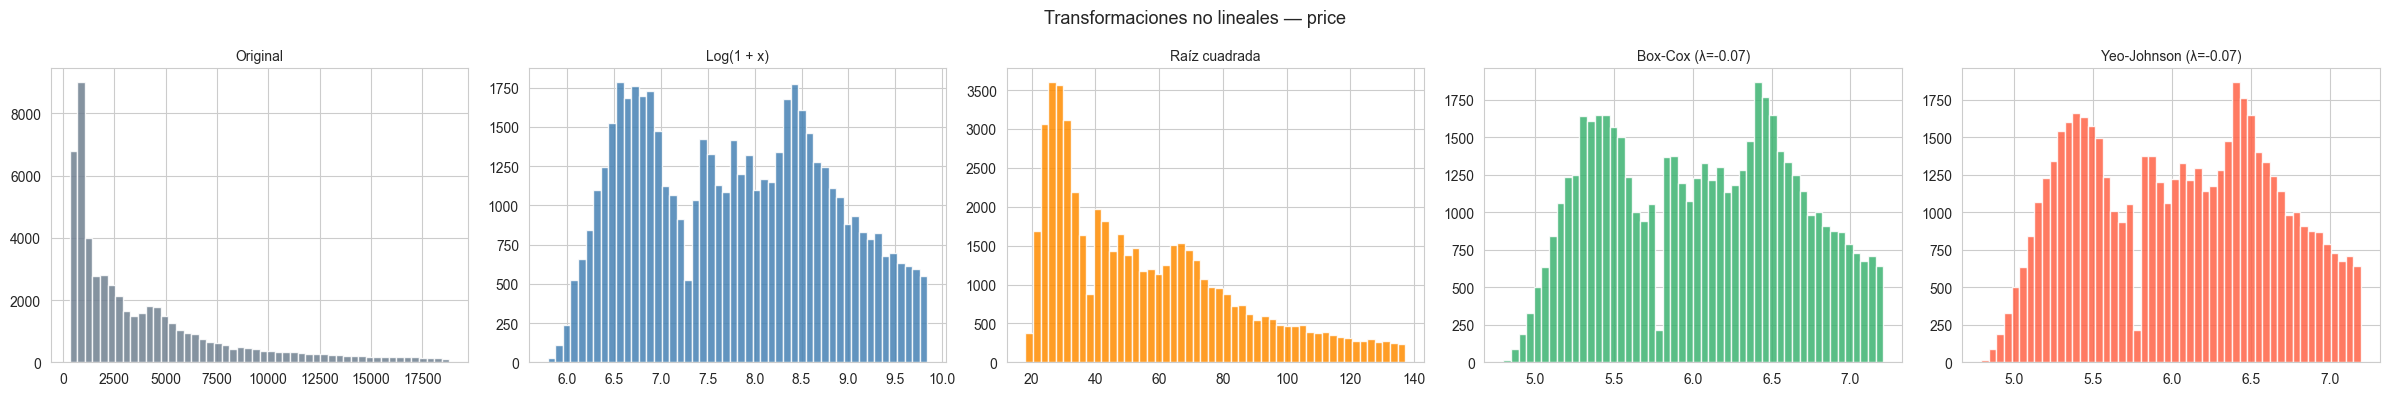

In [ ]:
price_bc, lambda_bc = boxcox(df['price'])
price_yj, lambda_yj = yeojohnson(df['price'])

fig, axes = plt.subplots(1, 5, figsize=(24, 4))

datos   = [df['price'], np.log1p(df['price']), np.sqrt(df['price']), price_bc, price_yj]
titulos = [
    'Original',
    'Log(1 + x)',
    'Raíz cuadrada',
    f'Box-Cox (λ={lambda_bc:.2f})',
    f'Yeo-Johnson (λ={lambda_yj:.2f})'
]
color_bars = ['slategray', 'steelblue', 'darkorange', 'mediumseagreen', 'tomato']

for ax, d, t, c in zip(axes, datos, titulos, color_bars):
    ax.hist(d, bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(t, fontsize=10)

plt.suptitle('Transformaciones no lineales — price', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
df['log_price']  = np.log1p(df['price'])
df['sqrt_price'] = np.sqrt(df['price'])

print(f'Skewness original : {df["price"].skew():.3f}')
print(f'Skewness log      : {df["log_price"].skew():.3f}')
print(f'Skewness sqrt     : {df["sqrt_price"].skew():.3f}')

Skewness original : 1.618
Skewness log      : 0.116
Skewness sqrt     : 0.844


## 2. Feature Scaling

<p align="center"><img src="https://miro.medium.com/max/2000/1*yR54MSI1jjnf2QeGtt57PA.png" width="400"></p>

Escaladores principales:

**Normalización:**
- **Min-Max:**
Escala los datos a un rango definido, típicamente entre 0 y 1.

$$
X_{std} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

- **MaxAbs:**
Similar a MinMaxScaler, pero mantiene la esparcidad de los datos, escalando al rango -1 a 1.

$$
X_{scaled} = \frac{X}{\max(|X|)}
$$



**Estandarización:**
- **Standard (Z-score):**
Convierte los datos a una distribución normal estándar con media 0 y desviación estándar 1.

$$
z = \frac{x - \mu}{\sigma}
$$

- **Robust:**
Usa mediana e IQR, resistente a outliers
Similar a StandardScaler, pero usa la mediana y el rango intercuartil (IQR) en lugar de la media y desviación estándar.

$$
x_{scaled} = \frac{x - \text{mediana}}{Q_3 - Q_1}
$$


Comparamos sobre `carat`, que tiene una distribución sesgada con outliers.

In [ ]:
carat = df[['carat']]

scaler_df = pd.DataFrame({'original': df['carat']})
scaler_df['min_max']  = MinMaxScaler().fit_transform(carat)
scaler_df['max_abs']  = MaxAbsScaler().fit_transform(carat)
scaler_df['standard'] = StandardScaler().fit_transform(carat)
scaler_df['robust']   = RobustScaler().fit_transform(carat)

scaler_df.describe().round(3)

,original,min_max,max_abs,standard,robust
count,53940.000,53940.000,53940.000,53940.000,53940.000
mean,0.798,0.124,0.159,0.000,0.153
std,0.474,0.099,0.095,1.000,0.741
min,0.200,0.000,0.040,-1.261,-0.781
25%,0.400,0.042,0.080,-0.840,-0.469
50%,0.700,0.104,0.140,-0.207,0.000
75%,1.040,0.175,0.208,0.511,0.531
max,5.010,1.000,1.000,8.886,6.734


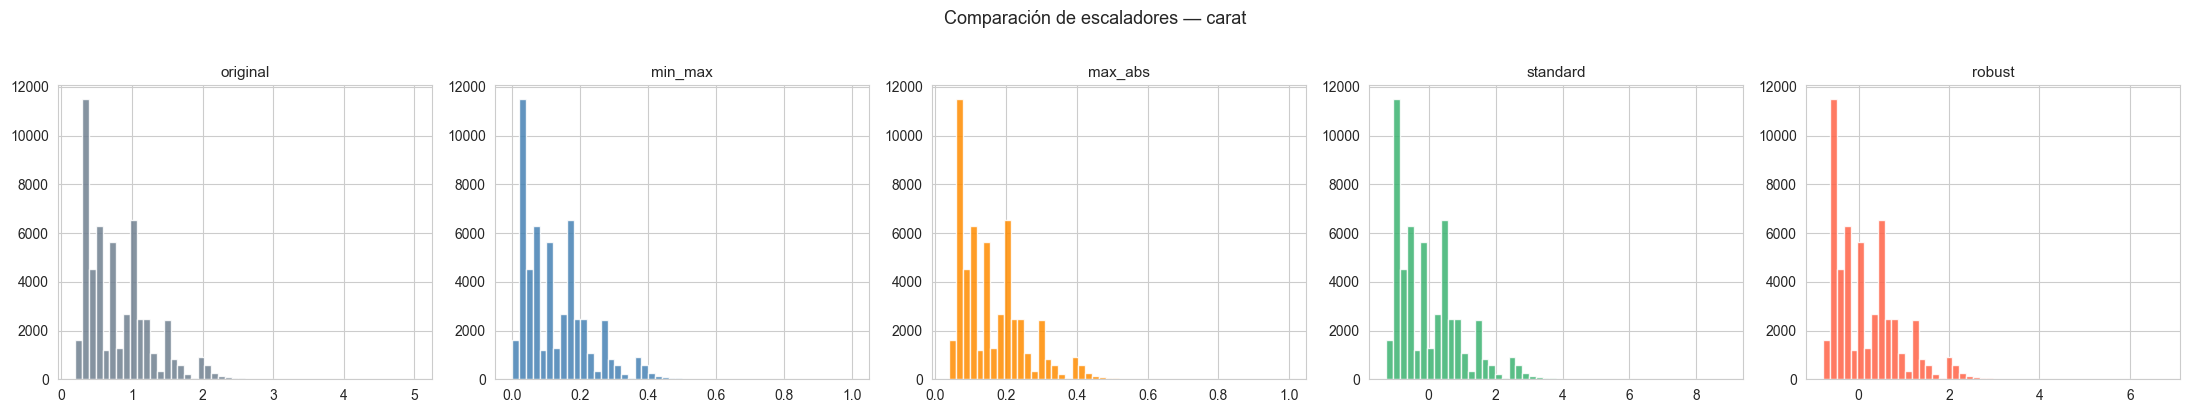

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
colores = ['slategray', 'steelblue', 'darkorange', 'mediumseagreen', 'tomato']

for ax, col, color in zip(axes, scaler_df.columns, colores):
    ax.hist(scaler_df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11)

plt.suptitle('Comparación de escaladores — carat', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Binning (Discretización)

Convertimos `carat` (continuo) en una variable categórica ordinal.  
Tres estrategias, cada una con diferentes implicancias:

In [ ]:
# 3.1 Equal Width — intervalos de igual tamaño en el rango
df['carat_ew'] = pd.cut(
    df['carat'], bins=5,
    labels=['muy_bajo', 'bajo', 'medio', 'alto', 'muy_alto']
)

# 3.2 Equal Frequency — mismo número de observaciones por bin (cuartiles)
df['carat_ef'] = pd.qcut(df['carat'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# 3.3 Ad-hoc: umbrales conocidos en el mercado de diamantes
cortes  = [0, 0.5, 1.0, 1.5, 2.0, float('inf')]
nombres = ['<0.5ct', '0.5-1ct', '1-1.5ct', '1.5-2ct', '>2ct']
df['carat_custom'] = pd.cut(df['carat'], bins=cortes, labels=nombres)

for col in ['carat_ew', 'carat_ef', 'carat_custom']:
    print(f'\n{col}:')
    print(df[col].value_counts().sort_index())


carat_ew:
carat_ew
muy_bajo    43781
bajo         9478
medio         667
alto           11
muy_alto        3
Name: count, dtype: int64

carat_ef:
carat_ef
Q1    14391
Q2    12771
Q3    13399
Q4    13379
Name: count, dtype: int64

carat_custom:
carat_custom
<0.5ct     18932
0.5-1ct    17506
1-1.5ct    12060
1.5-2ct     3553
>2ct        1889
Name: count, dtype: int64


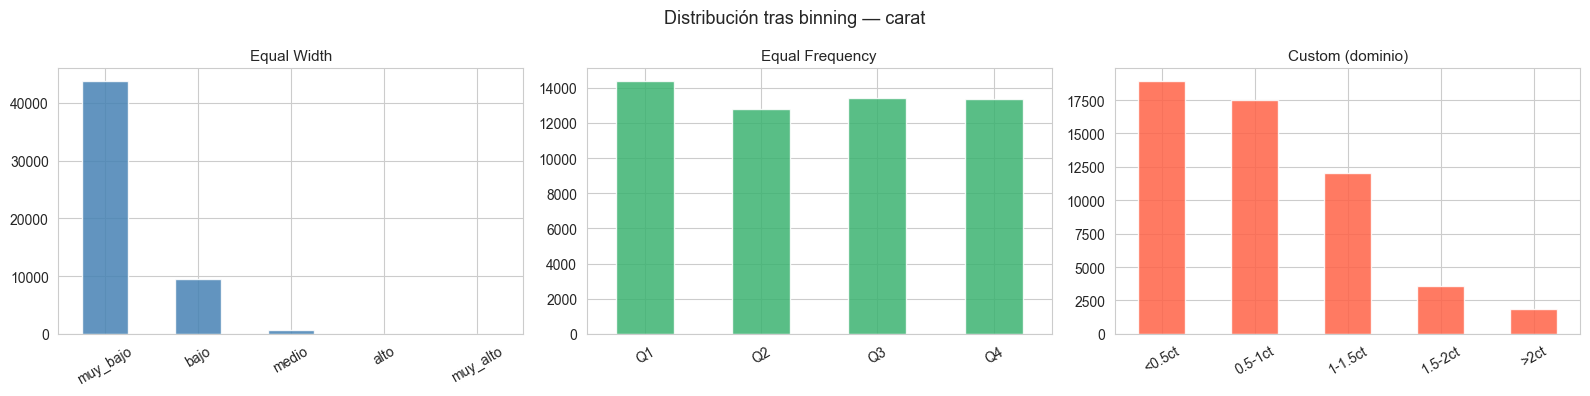

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, tit, col_bar in zip(
    axes,
    ['carat_ew', 'carat_ef', 'carat_custom'],
    ['Equal Width', 'Equal Frequency', 'Custom (dominio)'],
    ['steelblue', 'mediumseagreen', 'tomato']
):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=col_bar, edgecolor='white', alpha=0.85)
    ax.set_title(tit, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución tras binning — carat', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Precio promedio por tramo custom: el binning captura bien el efecto del quilataje
df.groupby('carat_custom')['price'].mean().round(0).sort_index()

carat_custom
<0.5ct      840.000
0.5-1ct    2811.000
1-1.5ct    6514.000
1.5-2ct   11322.000
>2ct      14951.000
Name: price, dtype: float64

## 4. Encoding

Transformamos variables categóricas en numéricas. Exploraremos distintas técnicas con distintas propiedades.

### 4.1 Ordinal Encoding

`cut`, `color` y `clarity` tienen un orden natural definido por la certificación GIA.  
Usamos `OrdinalEncoder` respetando ese orden (no el arbitrario de `LabelEncoder`).

In [ ]:
cut_orden     = [['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']]
color_orden   = [['J', 'I', 'H', 'G', 'F', 'E', 'D']]       # J = más amarillo, D = incoloro
clarity_orden = [['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']]

df['cut_ord']     = OrdinalEncoder(categories=cut_orden).fit_transform(df[['cut']]).astype(int)
df['color_ord']   = OrdinalEncoder(categories=color_orden).fit_transform(df[['color']]).astype(int)
df['clarity_ord'] = OrdinalEncoder(categories=clarity_orden).fit_transform(df[['clarity']]).astype(int)

(
    df[['cut', 'cut_ord', 'color', 'color_ord', 'clarity', 'clarity_ord']]
    .drop_duplicates()
    .sort_values('cut_ord')
)

,cut,cut_ord,color,color_ord,clarity,clarity_ord
51998,Fair,0,J,0,VVS2,5
4090,Fair,0,J,0,I1,0
3843,Fair,0,G,3,IF,7
506,Fair,0,I,1,VS1,4
3641,Fair,0,E,5,VVS2,5
...,...,...,...,...,...,...
123,Ideal,4,F,4,VS1,4
124,Ideal,4,G,3,VVS1,6
132,Ideal,4,E,5,VS1,4
88,Ideal,4,E,5,SI1,2


### 4.2 Rare Encoding

Las etiquetas raras son aquellas que aparecen solo en una pequeña proporción de las observaciones en un dataset. Estas pueden causar algunos problemas, especialmente con el *overfitting* y la generalización. La solución es agrupar esas etiquetas raras en una nueva categoría: `'otros'`

En el ejemplo se realizará con un umbral del **10%**: `Fair` (3%) y `Good` (9%) se fusionan.

In [ ]:
threshold = 0.10
freq_cut = df['cut'].value_counts(normalize=True)

print('Frecuencias de cut:')
print(freq_cut.round(3))

cats_raras = freq_cut[freq_cut < threshold].index.tolist()
print(f'\nCategorías bajo el {threshold*100:.0f}%: {cats_raras}')

df['cut_rare'] = df['cut'].apply(lambda x: 'otros' if x in cats_raras else x)

print('\nTras rare encoding:')
print(df['cut_rare'].value_counts(normalize=True).round(3))

Frecuencias de cut:
cut
Ideal       0.400
Premium     0.256
Very Good   0.224
Good        0.091
Fair        0.030
Name: proportion, dtype: float64

Categorías bajo el 10%: ['Good', 'Fair']

Tras rare encoding:
cut_rare
Ideal       0.400
Premium     0.256
Very Good   0.224
otros       0.121
Name: proportion, dtype: float64


In [ ]:
df[['cut', 'cut_rare']].tail(15)

,cut,cut_rare
53925,Premium,Premium
53926,Ideal,Ideal
53927,Fair,otros
53928,Premium,Premium
53929,Ideal,Ideal
53930,Ideal,Ideal
53931,Very Good,Very Good
53932,Ideal,Ideal
53933,Premium,Premium
53934,Ideal,Ideal


### 4.3 One-Hot Encoding (OHE)

Genera una columna binaria por categoría.  

__Ventajas__
- No asume la distribución de las categorías de la variable categórica.
- Conserva toda la información de la variable categórica.
- Adecuado para modelos lineales.

__Limitaciones__

- Expande el espacio de los features. Puede generar sparsity cuando hay muchas categorías.
- No agrega información adicional durante la codificación.

In [ ]:
cut_dummies = pd.get_dummies(df['cut'], prefix='cut', drop_first=False)
df = pd.concat([df, cut_dummies], axis=1)

print('Columnas OHE generadas:', cut_dummies.columns.tolist())
df[['cut'] + cut_dummies.columns.tolist()].head()

Columnas OHE generadas: ['cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good']


,cut,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good
0,Very Good,False,False,False,False,True
1,Ideal,False,False,True,False,False
2,Premium,False,False,False,True,False
3,Premium,False,False,False,True,False
4,Ideal,False,False,True,False,False


### 4.4 Frequency Encoding

Reemplazamos cada categoría por su frecuencia relativa en el dataset.

In [ ]:
freq_map = df['color'].value_counts(normalize=True).to_dict()
df['color_freq'] = df['color'].map(freq_map)

df.groupby('color').agg(
    frecuencia=('color_freq', 'first'),
    precio_medio=('price', 'mean')
).sort_values('frecuencia', ascending=False).round(1)

,frecuencia,precio_medio
color,,
G,0.200,3999.100
E,0.200,3076.800
F,0.200,3724.900
H,0.200,4486.700
D,0.100,3170.000
I,0.100,5091.900
J,0.100,5323.800


In [ ]:
df[['color', 'color_freq']].head(10)

,color,color_freq
0,F,0.177
1,F,0.177
2,F,0.177
3,J,0.052
4,E,0.182
5,H,0.154
6,D,0.126
7,G,0.209
8,F,0.177
9,I,0.101


### 4.5 Target Encoding

Reemplazamos cada categoría por la media del target (`price`).  
**Advertencia:** en producción debe aplicarse solo sobre el train set (dentro de CV) para evitar data leakage.

In [ ]:
target_map = df.groupby('color')['price'].mean().to_dict()
df['color_target_enc'] = df['color'].map(target_map)

df.groupby('color').agg(
    precio_real_medio=('price', 'mean'),
    target_encoding=('color_target_enc', 'first')
).round(1).sort_values('precio_real_medio')

,precio_real_medio,target_encoding
color,,
E,3076.800,3076.800
D,3170.000,3170.000
F,3724.900,3724.900
G,3999.100,3999.100
H,4486.700,4486.700
I,5091.900,5091.900
J,5323.800,5323.800


In [ ]:
df[['color', 'price', 'color_target_enc']].head(10)

,color,price,color_target_enc
0,F,752,3724.886
1,F,6059,3724.886
2,F,4257,3724.886
3,J,1909,5323.818
4,E,8158,3076.752
5,H,1893,4486.669
6,D,4155,3169.954
7,G,878,3999.136
8,F,4754,3724.886
9,I,15919,5091.875


## 5. Variables Temporales

Extraemos información de `sale_date`

In [ ]:
df["sale_date"] = pd.to_datetime(df["sale_date"], format="%d/%m/%Y")

# Extracción de componentes de la fecha
df['anio']          = df['sale_date'].dt.year
df['mes']           = df['sale_date'].dt.month
df['dia']           = df['sale_date'].dt.day
df['hora']          = df['sale_date'].dt.hour
df['dia_semana']    = df['sale_date'].dt.dayofweek    # 0=Lunes, 6=Domingo
df['trimestre']     = df['sale_date'].dt.quarter
df['semana_anio']   = df['sale_date'].dt.isocalendar().week.astype(int)
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)

df[['sale_date', 'anio', 'mes', 'dia', 'hora', 'dia_semana', 'trimestre', 'es_fin_semana']].head(8)

,sale_date,anio,mes,dia,hora,dia_semana,trimestre,es_fin_semana
0,2020-01-01,2020,1,1,0,2,1,0
1,2020-01-01,2020,1,1,0,2,1,0
2,2020-01-01,2020,1,1,0,2,1,0
3,2020-01-01,2020,1,1,0,2,1,0
4,2020-01-01,2020,1,1,0,2,1,0
5,2020-01-01,2020,1,1,0,2,1,0
6,2020-01-01,2020,1,1,0,2,1,0
7,2020-01-01,2020,1,1,0,2,1,0


In [ ]:
# Lag y ventana móvil — requieren orden cronológico
df_temp = df.sort_values('sale_date').reset_index(drop=True)

df_temp['precio_lag_1']        = df_temp['price'].shift(1)
df_temp['precio_lag_24']       = df_temp['price'].shift(24)
df_temp['precio_roll24_mean']  = df_temp['price'].rolling(window=24, min_periods=1).mean()
df_temp['precio_roll24_std']   = df_temp['price'].rolling(window=24, min_periods=1).std()

df_temp[['sale_date', 'price', 'precio_lag_1', 'precio_roll24_mean',
          'precio_roll24_std']].dropna().head(8).round(2)

,sale_date,price,precio_lag_1,precio_roll24_mean,precio_roll24_std
1,2020-01-01,5804,752.000,3278.000,3572.300
2,2020-01-01,1561,5804.000,2705.670,2713.550
3,2020-01-01,2054,1561.000,2542.750,2239.440
4,2020-01-01,2830,2054.000,2600.200,1943.660
5,2020-01-01,7300,2830.000,3383.500,2589.130
6,2020-01-01,827,7300.000,3018.290,2553.430
7,2020-01-01,2395,827.000,2940.380,2374.270
8,2020-01-01,5364,2395.000,3209.670,2363.290


## 6. Variables Agregadas

Enriquecemos cada fila con estadísticas de su grupo.  
La idea: si un diamante es `cut=Ideal`, ¿qué caracteriza típicamente a ese grupo?

In [ ]:
# Estadísticas de precio agrupadas por tipo de corte
agg_cut = df.groupby('cut')['price'].agg(
    precio_med_cut='mean',
    precio_std_cut='std',
    precio_max_cut='max',
    n_cut='count'
).reset_index()

df = df.merge(agg_cut, on='cut', how='left')

# Cada fila hereda las estadísticas de su grupo
df[['cut', 'price', 'precio_med_cut', 'precio_std_cut', 'n_cut']].head()


,cut,price,precio_med_cut,precio_std_cut,n_cut
0,Very Good,752,3981.760,3935.862,12082
1,Ideal,6059,3457.542,3808.401,21551
2,Premium,4257,4584.258,4349.205,13791
3,Premium,1909,4584.258,4349.205,13791
4,Ideal,8158,3457.542,3808.401,21551


In [ ]:
# Por clarity y por combinación cut + color
agg_clarity = df.groupby('clarity').agg(
    precio_med_clarity=('price', 'mean'),
    carat_med_clarity=('carat', 'mean'),
).reset_index()
df = df.merge(agg_clarity, on='clarity', how='left')

agg_cut_color = (
    df.groupby(['cut', 'color'])['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'precio_med_cut_color'})
)
df = df.merge(agg_cut_color, on=['cut', 'color'], how='left')

df[['cut', 'color', 'clarity', 'price', 'precio_med_clarity', 'precio_med_cut_color']].head()


,cut,color,clarity,price,precio_med_clarity,precio_med_cut_color
0,Very Good,F,VS2,752,3924.989,3778.820
1,Ideal,F,SI1,6059,3996.001,3374.939
2,Premium,F,SI2,4257,5063.029,4324.890
3,Premium,J,SI1,1909,3996.001,6294.592
4,Ideal,E,VS2,8158,3924.989,2597.550


In [ ]:
# Desviación porcentual del precio individual respecto a la media de su grupo de corte
df['precio_vs_cut_mean_pct'] = (df['price'] / df['precio_med_cut'] - 1) * 100
df[['cut', 'price', 'precio_med_cut', 'precio_vs_cut_mean_pct']].head()

,cut,price,precio_med_cut,precio_vs_cut_mean_pct
0,Very Good,752,3981.760,-81.114
1,Ideal,6059,3457.542,75.240
2,Premium,4257,4584.258,-7.139
3,Premium,1909,4584.258,-58.357
4,Ideal,8158,3457.542,135.948


## 7. Interacciones y Variables Derivadas

### 7.1 Ratios, productos y diferencias

In [ ]:
# x, y, z son dimensiones físicas del diamante en mm
df['volumen']           = df['x'] * df['y'] * df['z']
df['precio_por_carat']  = df['price'] / df['carat']
df['ratio_depth_table'] = df['depth'] / df['table']
df['carat_x_clarity']   = df['carat'] * df['clarity_ord']
df['carat_x_color']     = df['carat'] * df['color_ord']

df[['carat', 'x', 'y', 'z', 'volumen', 'precio_por_carat', 'ratio_depth_table']].head(6).round(3)

,carat,x,y,z,volumen,precio_por_carat,ratio_depth_table
0,0.380,4.730,4.790,2.840,64.345,1978.947,1.047
1,1.030,6.510,6.550,4.000,170.562,5882.524,1.095
2,1.010,6.430,6.380,3.960,162.453,4214.851,1.104
3,0.770,5.820,5.860,3.610,123.120,2479.221,1.047
4,1.090,6.660,6.670,4.040,179.466,7484.404,1.063
5,0.520,5.190,5.250,3.220,87.737,3640.385,1.164


### 7.2 Variables polinomiales

`carat` tiene una relación casi cuadrática con `price`.  
Las variables polinomiales permiten que modelos lineales capten esas curvas.

In [ ]:
df['carat_2'] = df['carat'] ** 2
df['carat_3'] = df['carat'] ** 3

# sklearn genera todas las combinaciones hasta grado 2
cols_poly = ['carat', 'depth', 'table']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_arr   = poly.fit_transform(df[cols_poly])
poly_names = poly.get_feature_names_out(cols_poly)

print('Features generadas por PolynomialFeatures:')
for name in poly_names:
    print(' •', name)

Features generadas por PolynomialFeatures:
 • carat
 • depth
 • table
 • carat^2
 • carat depth
 • carat table
 • depth^2
 • depth table
 • table^2


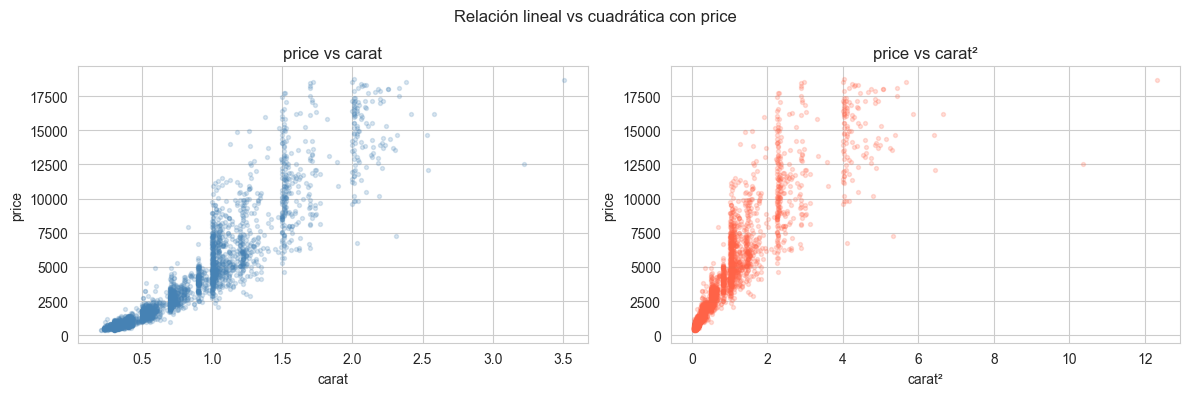

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = df.sample(3000, random_state=42)

axes[0].scatter(sample['carat'],   sample['price'], alpha=0.2, s=8, color='steelblue')
axes[0].set_title('price vs carat')
axes[0].set_xlabel('carat')
axes[0].set_ylabel('price')

axes[1].scatter(sample['carat_2'], sample['price'], alpha=0.2, s=8, color='tomato')
axes[1].set_title('price vs carat²')
axes[1].set_xlabel('carat²')
axes[1].set_ylabel('price')

plt.suptitle('Relación lineal vs cuadrática con price', fontsize=12)
plt.tight_layout()
plt.show()

### 7.3 Indicadores (Flags)

Variables binarias que capturan condiciones específicas.  
Son fáciles de interpretar y útiles para detectar segmentos.

In [ ]:
df['es_ideal']        = (df['cut'] == 'Ideal').astype(int)
df['es_premium_plus'] = df['cut'].isin(['Premium', 'Ideal']).astype(int)
df['es_caro']         = (df['price'] > df['price'].quantile(0.75)).astype(int)
df['claridad_alta']   = df['clarity'].isin(['VVS1', 'VVS2', 'IF']).astype(int)
df['color_premier']   = df['color'].isin(['D', 'E', 'F']).astype(int)

# Flag combinado: diamante de máxima calidad en los tres atributos
df['es_top_diamante'] = (
    (df['es_ideal'] == 1) &
    (df['claridad_alta'] == 1) &
    (df['color_premier'] == 1)
).astype(int)

flags = ['es_ideal', 'es_premium_plus', 'es_caro', 'claridad_alta', 'color_premier', 'es_top_diamante']
df[['cut', 'clarity', 'color', 'price'] + flags].head(10)


,cut,clarity,color,price,es_ideal,es_premium_plus,es_caro,claridad_alta,color_premier,es_top_diamante
0,Very Good,VS2,F,752,0,0,0,0,1,0
1,Ideal,SI1,F,6059,1,1,1,0,1,0
2,Premium,SI2,F,4257,0,1,0,0,1,0
3,Premium,SI1,J,1909,0,1,0,0,0,0
4,Ideal,VS2,E,8158,1,1,1,0,1,0
5,Ideal,VVS1,H,1893,1,1,0,1,0,0
6,Premium,SI2,D,4155,0,1,0,0,1,0
7,Premium,VVS2,G,878,0,1,0,1,0,0
8,Ideal,SI2,F,4754,1,1,0,0,1,0
9,Very Good,VS2,I,15919,0,0,1,0,0,0


## Resumen

In [ ]:
# Vista final del dataset enriquecido
cols_preview = [
    'carat', 'cut', 'color', 'clarity', 'price', 'sale_date',
    'log_price', 'carat_ew', 'cut_ord', 'color_freq', 'color_target_enc',
    'anio', 'mes', 'es_fin_semana',
    'precio_med_cut', 'precio_med_cut_color', 'precio_vs_cut_mean_pct',
    'volumen', 'precio_por_carat', 'carat_2', 'es_top_diamante'
]
df[cols_preview].head().round(3)

,carat,cut,color,clarity,price,sale_date,log_price,carat_ew,cut_ord,color_freq,...,anio,mes,es_fin_semana,precio_med_cut,precio_med_cut_color,precio_vs_cut_mean_pct,volumen,precio_por_carat,carat_2,es_top_diamante
0,0.380,Very Good,F,VS2,752,2020-01-01,6.624,muy_bajo,2,0.177,...,2020,1,0,3981.760,3778.820,-81.114,64.345,1978.947,0.144,0
1,1.030,Ideal,F,SI1,6059,2020-01-01,8.709,muy_bajo,4,0.177,...,2020,1,0,3457.542,3374.939,75.240,170.562,5882.524,1.061,0
2,1.010,Premium,F,SI2,4257,2020-01-01,8.357,muy_bajo,3,0.177,...,2020,1,0,4584.258,4324.890,-7.139,162.453,4214.851,1.020,0
3,0.770,Premium,J,SI1,1909,2020-01-01,7.555,muy_bajo,3,0.052,...,2020,1,0,4584.258,6294.592,-58.357,123.120,2479.221,0.593,0
4,1.090,Ideal,E,VS2,8158,2020-01-01,9.007,muy_bajo,4,0.182,...,2020,1,0,3457.542,2597.550,135.948,179.466,7484.404,1.188,0
